# RenAIssance — GSoC 2026 · Historical Manuscript OCR

> **Task II:** Fine-tune a Vision-Language Model to transcribe early modern Spanish/Portuguese manuscripts (1500–1900).

Two approaches are explored in this notebook:
- **Approach 1:** Qwen2.5-VL-7B fine-tuned via LoRA (Unsloth)
- **Approach 2:** Refined inference with hallucination guardrails + Tesseract baseline comparison *(better results)*

## Approach 1: Qwen2.5-VL + LoRA Fine-Tuning

### 1.1 Install Dependencies

In [ ]:
# GSOC 2026 | Human-AI (renAIssance) | Task II: Handwritten OCR
# Model: Qwen2.5-VL-7B fine-tuned with Unsloth (4-bit QLoRA)

# Unsloth auto-installs the correct CUDA version
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --upgrade trl transformers accelerate peft -q
!pip install pymupdf python-docx jiwer rapidfuzz nltk datasets -q

import nltk
nltk.download('punkt', quiet=True)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.6/401.6 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 13.3 MB

True

### 1.2 Core Imports

In [ ]:
# import os, re, json, random, unicodedata
# from pathlib import Path
# from typing import Dict, List, Tuple, Optional
# from collections import Counter

# import numpy as np
# import torch
# from PIL import Image, ImageEnhance, ImageFilter

# # Unsloth VLM
# from unsloth import FastVisionModel
# from unsloth.trainer import UnslothVisionDataCollator

# # Training
# from transformers import TrainingArguments
# from trl import SFTTrainer

# # Document parsing
# import fitz                           # PyMuPDF
# from docx import Document as DocxDoc

# # Metrics
# from jiwer import cer, wer
# from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# SEED = 42
# random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
#     print(f"GPU: {torch.cuda.get_device_name(0)}  {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# GSOC 2026 | Human-AI (renAIssance) | Task II: Handwritten OCR
# Model: Qwen2.5-VL-7B fine-tuned with Unsloth (4-bit QLoRA)

# 1. Install dependencies (Run once)
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
# !pip install --upgrade trl transformers accelerate peft -q
# !pip install pymupdf python-docx jiwer rapidfuzz nltk datasets -q

import os
import re
import json
import random
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import Counter

import numpy as np
import torch
from PIL import Image, ImageEnhance, ImageFilter

# NLTK Setup
import nltk
nltk.download('punkt', quiet=True)

# Unsloth VLM
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# Training
from transformers import TrainingArguments
from trl import SFTTrainer

# Document parsing
import fitz                           # PyMuPDF
from docx import Document as DocxDoc

# Metrics
from jiwer import cer, wer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


GPU Detected: Tesla T4
Memory: 15.6 GB


### 1.3 Mount Drive & Configure Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PDF_DIR  = Path("/content/drive/MyDrive/x_train")   # PDF files
DOCX_DIR = Path("/content/drive/MyDrive/y_train")   # DOCX files

WORKSPACE   = Path("/content/RenAIssance")
IMAGES_DIR  = WORKSPACE / "images"
DATASET_DIR = WORKSPACE / "dataset"
CHECKPOINTS = WORKSPACE / "checkpoints"
OUTPUT_DIR  = WORKSPACE / "outputs"

for d in [IMAGES_DIR, DATASET_DIR, CHECKPOINTS, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Verify folders exist
for label, folder in [("x_train (PDFs)", PDF_DIR), ("y_train (DOCX)", DOCX_DIR)]:
    files = list(folder.iterdir()) if folder.exists() else []
    print(f"  {label}: {len(files)} files found in {folder}")
    for f in files:
        print(f"    → {f.name}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  x_train (PDFs): 5 files found in /content/drive/MyDrive/x_train
    → AHPG-GPAH AU61&#x3a_2 – 1606.pdf
    → Pleito entre el Marqués de Viana.pdf
    → PT3279&#x3a_146&#x3a_342 – 1857.pdf
    → ES.28079.AHN&#x3a_&#x3a_INQUISICIÓN,1667,Exp.12 – 1640.pdf
    → AHPG-GPAH 1&#x3a_1716,A.35 – 1744.pdf
  y_train (DOCX): 6 files found in /content/drive/MyDrive/y_train
    → .~lock.AHPG-GPAH 1.1716,A.35 – 1744_transcription.docx#
    → ES.28079.AHN.INQUISICIÓN,1667,Exp.12 – 1640_transcription.docx
    → PT3279.146.342 – 1857_transcription.docx
    → Pleito entre el Marqués de Viana_transcription.docx
    → AHPG-GPAH 1.1716,A.35 – 1744_transcription.docx
    → AHPG-GPAH AU61.2 – 1606_transcription.docx


### 1.4 Discover Source Documents

Auto-discover all PDF and DOCX files from the dataset directories.

In [ ]:
import difflib

pdf_files  = sorted(PDF_DIR.glob("*.pdf"))
docx_files = sorted(DOCX_DIR.glob("*.docx"))

print(f"PDFs  found : {len(pdf_files)}")
print(f"DOCXs found : {len(docx_files)}")

def fuzzy_match(pdf_stem: str, docx_stems: list) -> str:
    """Find closest DOCX name for a given PDF stem."""
    # Normalize: lowercase, remove separators
    def norm(s):
        return re.sub(r'[-_.\s]', '', s.lower())
    pdf_n = norm(pdf_stem)
    scores = [(ds, difflib.SequenceMatcher(None, pdf_n, norm(ds)).ratio())
              for ds in docx_stems]
    best = max(scores, key=lambda x: x[1])
    return best[0] if best[1] > 0.4 else None

def guess_year(stem: str) -> int:
    match = re.search(r'(1[5-9]\d{2})', stem)
    return int(match.group(1)) if match else 1700

def guess_lang(stem: str) -> str:
    # PT3279 is Portuguese, everything else is Spanish
    return "pt" if stem.upper().startswith("PT") else "es"

docx_stems = [f.stem for f in docx_files]

DOCUMENT_MAP = {}
for pdf in pdf_files:
    matched_docx = fuzzy_match(pdf.stem, docx_stems)
    DOCUMENT_MAP[pdf.stem] = {
        "docx": matched_docx,
        "year": guess_year(pdf.stem),
        "lang": guess_lang(pdf.stem),
    }

print("\n── Auto-matched PDF → DOCX ──────────────────────────")
for pdf_stem, meta in DOCUMENT_MAP.items():
    status = "✅" if meta["docx"] else "❌ NO MATCH"
    print(f"  {status} {pdf_stem}")
    print(f"       → {meta['docx']}  (year={meta['year']}, lang={meta['lang']})")

PDFs  found : 5
DOCXs found : 5

── Auto-matched PDF → DOCX ──────────────────────────
  ✅ AHPG-GPAH 1&#x3a_1716,A.35 – 1744
       → AHPG-GPAH 1.1716,A.35 – 1744_transcription  (year=1716, lang=es)
  ✅ AHPG-GPAH AU61&#x3a_2 – 1606
       → AHPG-GPAH AU61.2 – 1606_transcription  (year=1606, lang=es)
  ✅ ES.28079.AHN&#x3a_&#x3a_INQUISICIÓN,1667,Exp.12 – 1640
       → ES.28079.AHN.INQUISICIÓN,1667,Exp.12 – 1640_transcription  (year=1667, lang=es)
  ✅ PT3279&#x3a_146&#x3a_342 – 1857
       → PT3279.146.342 – 1857_transcription  (year=1857, lang=pt)
  ✅ Pleito entre el Marqués de Viana
       → Pleito entre el Marqués de Viana_transcription  (year=1700, lang=es)


### 1.5 DOCX Ground-Truth Loader

In [ ]:
def get_docx_path(docx_stem: str) -> Path:
    """Find the DOCX file in y_train folder by stem name."""
    # Exact match first
    exact = DOCX_DIR / f"{docx_stem}.docx"
    if exact.exists():
        return exact
    # Fuzzy fallback — handle Drive HTML-encoding quirks
    for f in DOCX_DIR.glob("*.docx"):
        if difflib.SequenceMatcher(None,
            re.sub(r'[-_.\s]','', f.stem.lower()),
            re.sub(r'[-_.\s]','', docx_stem.lower())).ratio() > 0.75:
            print(f"  [fuzzy match] {docx_stem} → {f.name}")
            return f
    return exact  # will fail gracefully in parse_docx_pages

print("DOCX path resolution check:")
for pdf_stem, meta in DOCUMENT_MAP.items():
    if meta["docx"]:
        p = get_docx_path(meta["docx"])
        exists = "✅" if p.exists() else "❌ MISSING"
        print(f"  {exists}  {p.name}")


DOCX path resolution check:
  ✅  AHPG-GPAH 1.1716,A.35 – 1744_transcription.docx
  ✅  AHPG-GPAH AU61.2 – 1606_transcription.docx
  ✅  ES.28079.AHN.INQUISICIÓN,1667,Exp.12 – 1640_transcription.docx
  ✅  PT3279.146.342 – 1857_transcription.docx
  ✅  Pleito entre el Marqués de Viana_transcription.docx


### 1.6 PDF → Page Images

Convert each PDF page to a resized RGB image for model input.

In [ ]:
def pdf_to_images(
    pdf_path:   Path,
    output_dir: Path,
    dpi:        int   = 150,
    max_size:   Tuple = (768, 1024)
) -> Dict[int, Path]:
    """
    Render every PDF page to a preprocessed JPEG.
    Returns: {page_num_1indexed: image_path}
    """
    doc      = fitz.open(str(pdf_path))
    src_dir  = output_dir / pdf_path.stem
    src_dir.mkdir(parents=True, exist_ok=True)

    zoom   = dpi / 72
    matrix = fitz.Matrix(zoom, zoom)
    result = {}

    for idx in range(len(doc)):
        pixmap = doc[idx].get_pixmap(matrix=matrix)
        img    = Image.frombytes("RGB", (pixmap.width, pixmap.height), pixmap.samples)

        # Preprocess for VLM (soft contrast, no binarisation)
        img.thumbnail(max_size, Image.LANCZOS)
        img = ImageEnhance.Contrast(img).enhance(1.4)
        img = img.filter(ImageFilter.SHARPEN)

        out_path = src_dir / f"page{idx+1:04d}.jpg"
        img.save(str(out_path), "JPEG", quality=85)
        result[idx + 1] = out_path

    doc.close()
    print(f"  {pdf_path.name}: {len(result)} pages extracted")
    return result


print("Extracting PDF pages to JPEG …")
ALL_PAGE_IMAGES: Dict[str, Dict[int, Path]] = {}

for pdf_stem in DOCUMENT_MAP:
    pdf_path = PDF_DIR / f"{pdf_stem}.pdf"
    if pdf_path.exists():
        ALL_PAGE_IMAGES[pdf_stem] = pdf_to_images(pdf_path, IMAGES_DIR)
    else:
        print(f"  PDF NOT FOUND: {pdf_path}")

total_pages = sum(len(v) for v in ALL_PAGE_IMAGES.values())
print(f"\nTotal pages extracted: {total_pages}")


Extracting PDF pages to JPEG …
  AHPG-GPAH 1&#x3a_1716,A.35 – 1744.pdf: 3 pages extracted
  AHPG-GPAH AU61&#x3a_2 – 1606.pdf: 3 pages extracted
  ES.28079.AHN&#x3a_&#x3a_INQUISICIÓN,1667,Exp.12 – 1640.pdf: 11 pages extracted
  PT3279&#x3a_146&#x3a_342 – 1857.pdf: 3 pages extracted
  Pleito entre el Marqués de Viana.pdf: 15 pages extracted

Total pages extracted: 35


### 1.7 Build Training Pairs

Match each PDF page image with its DOCX ground-truth text to create `(image, transcript)` pairs.

In [ ]:
import json
import random
import numpy as np
from pathlib import Path
from typing import Dict, List
from PIL import Image, ImageEnhance
from docx import Document as DocxDoc

# Ensure you have your global variables defined before running this!
# e.g., DOCUMENT_MAP, DOCX_DIR, ALL_PAGE_IMAGES, DATASET_DIR, SEED = 42


def parse_docx_pages(docx_path: Path) -> Dict[int, str]:
    """Parses a DOCX and attempts to extract text page-by-page."""
    doc = DocxDoc(docx_path)
    pages = {}
    current_page = 1
    current_text = []

    for para in doc.paragraphs:
        if 'lastRenderedPageBreak' in para._element.xml or 'w:br" w:type="page' in para._element.xml:
            pages[current_page] = "\n".join(current_text)
            current_page += 1
            current_text = [para.text]
        else:
            current_text.append(para.text)

    if current_text:
        pages[current_page] = "\n".join(current_text)

    return pages

def augment_and_slice(img: Image.Image, text: str, rng: np.random.Generator) -> List[Dict]:
    """Applies rotation up to 10 degrees and cuts 2-4 line segments."""
    variants = []
    w, h = img.size
    lines = [l for l in text.split('\n') if len(l.strip()) > 2]

    # --- A. Full Page Augmentation (Rotation 10°) ---
    angle = float(rng.uniform(-10.0, 10.0))
    full_rot = img.rotate(angle, resample=Image.BICUBIC, fillcolor=(255, 255, 255), expand=True)
    full_rot = ImageEnhance.Contrast(full_rot).enhance(float(rng.uniform(0.8, 1.2)))
    variants.append({"image": full_rot, "text": text, "type": "full_rot"})

    # --- B. Strip Cropping (The Multiplier) ---
    if len(lines) >= 4:
        for i in range(2): # Create 2 random crops per page
            num_lines = rng.integers(2, 5) # 2 to 4 lines
            start_idx = rng.integers(0, len(lines) - num_lines)
            selected_text = "\n".join(lines[start_idx : start_idx + num_lines])

            # Estimate coordinates (Vertical slice)
            top = int((start_idx / len(lines)) * h)
            bottom = int(((start_idx + num_lines) / len(lines)) * h)

            # Add padding so handwriting isn't cut off tightly
            pad = (bottom - top) // 10
            crop = img.crop((0, max(0, top-pad), w, min(h, bottom+pad)))
            variants.append({"image": crop, "text": selected_text, "type": f"crop_{i}"})

    return variants


def build_training_pairs() -> List[Dict]:
    pairs = []
    for pdf_stem, meta in DOCUMENT_MAP.items():
        docx_path = DOCX_DIR / f"{meta['docx']}.docx"
        if not docx_path.exists():
            print(f"  [SKIP] No DOCX for {pdf_stem}")
            continue

        gt_pages  = parse_docx_pages(docx_path)           # Y_train
        img_pages = ALL_PAGE_IMAGES.get(pdf_stem, {})     # X_train

        matched = 0
        for page_num, gt_text in gt_pages.items():
            if page_num in img_pages:
                pairs.append({
                    "image_path": str(img_pages[page_num]),
                    "gt_text":    gt_text.strip(),
                    "page_num":   page_num,
                    "source_id":  pdf_stem,
                    "year":       meta["year"],
                    "lang":       meta["lang"],
                    "is_synthetic": False,
                })
                matched += 1

        print(f"  {pdf_stem}: {matched} / {len(gt_pages)} GT pages mapped")

    print(f"\n✓ Total hand-mapped REAL pairs: {len(pairs)}")
    return pairs

REAL_PAIRS = build_training_pairs()


SYNTHETIC_DIR = DATASET_DIR / "augmented_images"
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)

AUGMENTED_PAIRS = []
MULTIPLIER = 5 # Generates 5 variations per real page

print(f"\n🚀 Augmenting {len(REAL_PAIRS)} pairs ({MULTIPLIER}x multiplier)...")

for pair in REAL_PAIRS:
    try:
        orig = Image.open(pair["image_path"]).convert("RGB")
    except Exception as e:
        print(f"Error opening {pair['image_path']}: {e}")
        continue

    for m in range(MULTIPLIER):
        results = augment_and_slice(orig, pair["gt_text"], rng)

        for res in results:
            # Save the augmented image
            fname = f"{Path(pair['image_path']).stem}_m{m}_{res['type']}.jpg"
            fpath = SYNTHETIC_DIR / fname
            res["image"].save(fpath, "JPEG", quality=85)

            # Create the metadata dictionary
            new_entry = pair.copy()
            new_entry.update({
                "image_path": str(fpath),
                "gt_text": res["text"],
                "is_synthetic": True,
                "aug_type": res["type"]
            })
            AUGMENTED_PAIRS.append(new_entry)

print(f"✓ Generated {len(AUGMENTED_PAIRS)} synthetic/augmented pairs.")


FINAL_DATASET = REAL_PAIRS + AUGMENTED_PAIRS
random.shuffle(FINAL_DATASET)

pairs_file = DATASET_DIR / "final_training_manifest.json"
with open(pairs_file, "w", encoding="utf-8") as f:
    json.dump(FINAL_DATASET, f, ensure_ascii=False, indent=2)

print(f"\n✅ Pipeline Complete!")
print(f"Final Dataset Size: {len(FINAL_DATASET)} total pairs.")
print(f"Manifest saved → {pairs_file}")

  AHPG-GPAH 1&#x3a_1716,A.35 – 1744: 1 / 1 GT pages mapped
  AHPG-GPAH AU61&#x3a_2 – 1606: 1 / 1 GT pages mapped
  ES.28079.AHN&#x3a_&#x3a_INQUISICIÓN,1667,Exp.12 – 1640: 1 / 1 GT pages mapped
  PT3279&#x3a_146&#x3a_342 – 1857: 1 / 1 GT pages mapped
  Pleito entre el Marqués de Viana: 1 / 1 GT pages mapped

✓ Total hand-mapped REAL pairs: 5

🚀 Augmenting 5 pairs (5x multiplier)...
✓ Generated 75 synthetic/augmented pairs.

✅ Pipeline Complete!
Final Dataset Size: 80 total pairs.
Manifest saved → /content/RenAIssance/dataset/final_training_manifest.json


### 1.8 Augment with IAM Handwriting Samples


In [ ]:
from typing import List, Dict

def load_iam_samples(n: int = 150) -> List[Dict]:
    from datasets import load_dataset

    # A list of reliable IAM handwriting repositories on Hugging Face
    hf_datasets = [
        "Teklia/IAM-line",          # Highly reliable, standard line-level
        "alpayariyak/IAM_Sentences", # Good sentence-level fallback
        "nielsr/iam-lines"          # Common tutorial fallback
    ]

    for repo in hf_datasets:
        print(f"Attempting to load handwriting data from: {repo}...")
        try:
            # streaming=True prevents downloading the entire multi-GB dataset
            ds = load_dataset(repo, split="train", streaming=True)
            out = []

            for item in ds:
                if len(out) >= n:
                    break

                # Different repos use different keys for the text transcript
                img_val = item.get("image")
                text_val = item.get("text") or item.get("label") or item.get("transcription")

                if img_val and text_val:
                    out.append({
                        "pil_image":    img_val.convert("RGB"),
                        "image_path":   None, # Kept as None since it's loaded directly into memory
                        "gt_text":      str(text_val).strip(),
                        "page_num":     0,
                        "source_id":    f"IAM_{repo.split('/')[0]}",
                        "year":         1900, # Approximate era of the written text style
                        "lang":         "en",
                        "is_synthetic": False,
                    })

            if out:
                print(f"✓ Successfully loaded {len(out)} pre-warm samples from {repo}!")
                return out

        except Exception as e:
            print(f"  [Failed] Could not load from {repo}: {e}")
            continue

    print("⚠️ All IAM dataset attempts failed. Proceeding with your specific dataset only.")
    return []

# Run the loader
IAM_SAMPLES = load_iam_samples(150)

Attempting to load handwriting data from: Teklia/IAM-line...


README.md: 0.00B [00:00, ?B/s]

✓ Successfully loaded 150 pre-warm samples from Teklia/IAM-line!


### 1.9 Train / Validation Split

Split by document (not by page) to prevent data leakage across the train and validation sets.

In [ ]:
from torch.utils.data import Dataset
from typing import Dict, List
from PIL import Image
import random
val_split_size = max(1, int(len(REAL_PAIRS) * 0.15))

real_pairs_shuffled = REAL_PAIRS.copy()
random.shuffle(real_pairs_shuffled)

# Strict Validation Set (Real images only, completely unseen)
VAL_PAIRS = real_pairs_shuffled[:val_split_size]

# Base Training Set (Real images)
base_train_real = real_pairs_shuffled[val_split_size:]

# Filter Augmented data to only include augmentations of our base train set
train_identifiers = {f"{p['source_id']}_page_{p['page_num']}" for p in base_train_real}
train_augmented = [
    p for p in AUGMENTED_PAIRS
    if f"{p['source_id']}_page_{p['page_num']}" in train_identifiers
]

TRAIN_PAIRS = base_train_real + train_augmented
random.shuffle(TRAIN_PAIRS)

print("\n📊 Dataset Split Complete:")
print(f"  Validation: {len(VAL_PAIRS)} (Real pages only)")
print(f"  Training:   {len(TRAIN_PAIRS)} ({len(base_train_real)} Real + {len(train_augmented)} Augmented)")


OCR_PROMPT = (
    "Transcribe this historical manuscript page ({year}, {lang}) exactly as written. "
    "Preserve original spelling, abbreviations, and line breaks. "
    "Use [illegible] for unreadable words. Do NOT modernise the text."
)

def make_sample(pair: Dict) -> Dict:
    """Convert a training pair into Unsloth's VLM conversation format."""
    if pair.get("pil_image"):
        image = pair["pil_image"]
    else:
        image = Image.open(pair["image_path"]).convert("RGB")

    lang  = "Spanish" if pair.get("lang","es") == "es" else "Portuguese"
    year  = pair.get("year", 1700)

    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": OCR_PROMPT.format(year=year, lang=lang)}
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": pair["gt_text"]}
            ]}
        ],
        "images": [image]
    }

class ManuscriptDataset(Dataset):
    def __init__(self, pairs: List[Dict], extra: List[Dict] = None):
        if extra is None:
            extra = []
        self.pairs = pairs + extra

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return make_sample(self.pairs[idx])

# Initialize the final datasets
train_ds = ManuscriptDataset(TRAIN_PAIRS, IAM_SAMPLES)
val_ds   = ManuscriptDataset(VAL_PAIRS)

print("\n🚀 Unsloth Datasets Ready!")
print(f"  Final train_ds size: {len(train_ds)} (includes {len(IAM_SAMPLES)} IAM pre-warm samples)")
print(f"  Final val_ds size:   {len(val_ds)}")



📊 Dataset Split Complete:
  Validation: 1 (Real pages only)
  Training:   64 (4 Real + 60 Augmented)

🚀 Unsloth Datasets Ready!
  Final train_ds size: 214 (includes 150 IAM pre-warm samples)
  Final val_ds size:   1


### 1.10 Dataset Class & OCR Prompt

In [ ]:
from torch.utils.data import Dataset

OCR_PROMPT = (
    "Transcribe this historical manuscript page ({year}, {lang}) exactly as written. "
    "Preserve original spelling, abbreviations, and line breaks. "
    "Note that the letters 'u' and 'v' are often used interchangeably; transcribe them exactly as they appear visually without auto-correcting. "
    "Use [illegible] for unreadable words. Do NOT modernise the text."
)

def make_sample(pair: Dict) -> Dict:
    """Convert a training pair into Unsloth's VLM conversation format."""
    image = (pair["pil_image"] if pair.get("pil_image")
             else Image.open(pair["image_path"]).convert("RGB"))
    lang  = "Spanish" if pair.get("lang","es") == "es" else "Portuguese"
    year  = pair.get("year", 1700)

    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text",
                 "text": OCR_PROMPT.format(year=year, lang=lang)}
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": pair["gt_text"]}
            ]}
        ],
        "images": [image]
    }


class ManuscriptDataset(Dataset):
    def __init__(self, pairs: List[Dict], extra: List[Dict] = []):
        self.pairs = pairs + extra
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        return make_sample(self.pairs[idx])


train_ds = ManuscriptDataset(TRAIN_PAIRS, IAM_SAMPLES)
val_ds   = ManuscriptDataset(VAL_PAIRS)
print(f"Train dataset: {len(train_ds)} | Val dataset: {len(val_ds)}")


Train dataset: 214 | Val dataset: 1


### 1.11 Load Qwen2.5-VL-7B in 4-bit

Load the base model with 4-bit quantisation and gradient checkpointing to fit within a 15 GB GPU.

In [ ]:
# Qwen2.5-VL-7B scores 864 on OCRBench — highest among open VLMs
# 4-bit + gradient checkpointing fits comfortably in 15.6 GB T4

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit",
    load_in_4bit              = True,
    use_gradient_checkpointing = "unsloth",   # handles long manuscript pages
    max_seq_length            = 2048,
)

print(f"Loaded. Total params: {sum(p.numel() for p in model.parameters()):,}")


==((====))==  Unsloth 2026.3.9: Fast Qwen2_5_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.90G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

Loaded. Total params: 5,029,522,432


### 1.12 Attach LoRA Adapter

Fine-tune both the vision encoder and the language decoder with LoRA rank-16 adapters.

In [ ]:
# Fine-tune BOTH vision encoder and language decoder for manuscript OCR

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r            = 16,
    lora_alpha   = 32,
    lora_dropout = 0.05,
    bias         = "none",
    random_state = SEED,
    use_rslora   = False,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Trainable: 51,521,536 / 5,081,043,968 (1.01%)


### 1.13 Fine-Tune with SFTTrainer

In [ ]:
# Fine-Tune with SFTTrainer (FIXED)

import unsloth
from unsloth.trainer import UnslothVisionDataCollator

# 2. Import SFTConfig from trl instead of TrainingArguments from transformers
from trl import SFTTrainer, SFTConfig
import torch

# Prepare model for Unsloth training optimizations
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    dataset_kwargs = {"skip_prepare_dataset": True},

    # 3. Use SFTConfig
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,        # effective batch = 4
        warmup_steps                = 5,
        num_train_epochs            = 5,
        learning_rate               = 2e-4,
        fp16          = not torch.cuda.is_bf16_supported(),
        bf16          = torch.cuda.is_bf16_supported(),
        logging_steps = 5,
        optim         = "adamw_8bit",
        weight_decay  = 0.01,
        lr_scheduler_type = "cosine",
        seed       = SEED,
        output_dir = str(CHECKPOINTS),


        save_strategy  = "epoch",
        eval_strategy  = "epoch",

        load_best_model_at_end = True,
        metric_for_best_model  = "eval_loss",
        save_total_limit       = 3,
        report_to              = "none",
        remove_unused_columns  = False,
        dataloader_num_workers = 0,
    ),
)

print("Starting Unsloth fine-tuning …")
stats = trainer.train()
print(f"\nTraining complete!  Final loss: {stats.training_loss:.4f}")

best_path = CHECKPOINTS / "best_adapter"
best_path.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(best_path))
tokenizer.save_pretrained(str(best_path))
print(f"✅ Adapter saved locally → {best_path}")

# DRIVE_ROOT was removed — use PDF_DIR.parent instead
drive_ckpt = PDF_DIR.parent / "checkpoints" / "best_adapter"
drive_ckpt.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(drive_ckpt))
tokenizer.save_pretrained(str(drive_ckpt))
print(f"✅ Adapter backed up to Drive → {drive_ckpt}")

Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Unsloth fine-tuning …


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 214 | Num Epochs = 5 | Total steps = 270
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 51,521,536 of 8,343,688,192 (0.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.383871,1.420502
2,0.083690,2.824389
3,0.008125,3.163013
4,0.013296,3.231294
5,0.017988,3.262783


Unsloth: Not an error, but Qwen2_5_VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



Training complete!  Final loss: 0.3438
✅ Adapter saved locally → /content/RenAIssance/checkpoints/best_adapter
✅ Adapter backed up to Drive → /content/drive/MyDrive/checkpoints/best_adapter


### 1.14 Inference — Transcribe All Pages

In [ ]:
import torch
from PIL import Image
from transformers import GenerationConfig
from typing import Dict

FastVisionModel.for_inference(model)

DTYPE  = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
model  = model.to(DTYPE)

GEN_CONFIG = GenerationConfig(
    max_new_tokens = 1024,
    do_sample      = False,     # greedy — best for OCR transcription
    use_cache      = True,
    # do NOT set max_length here — avoids the conflict warning
)

def transcribe(image: Image.Image, year: int, lang: str) -> str:
    """Run fine-tuned Qwen2.5-VL on one manuscript page."""
    lang_name = "Spanish" if lang == "es" else "Portuguese"
    messages  = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text",
             "text": OCR_PROMPT.format(year=year, lang=lang_name)}
        ]
    }]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(
        image, input_text,
        add_special_tokens = False,
        return_tensors     = "pt"
    ).to("cuda", dtype=DTYPE)          # ← cast inputs to same dtype as model

    with torch.no_grad(), torch.autocast("cuda", dtype=DTYPE):   # ← key fix
        out_ids = model.generate(
            **inputs,
            generation_config = GEN_CONFIG,
        )

    new_tokens = out_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


ALL_TRANSCRIPTIONS: Dict[str, Dict[int, str]] = {}
print("=== Transcribing all pages ===\n")

for pdf_stem, meta in DOCUMENT_MAP.items():
    ALL_TRANSCRIPTIONS[pdf_stem] = {}
    src_out = OUTPUT_DIR / pdf_stem
    src_out.mkdir(exist_ok=True)

    pages = ALL_PAGE_IMAGES.get(pdf_stem, {})
    for page_num, img_path in pages.items():
        img  = Image.open(str(img_path)).convert("RGB")
        pred = transcribe(img, meta["year"], meta["lang"])
        ALL_TRANSCRIPTIONS[pdf_stem][page_num] = pred
        (src_out / f"page{page_num:04d}.txt").write_text(pred, encoding="utf-8")
        print(f"  [{pdf_stem}] p{page_num}: {pred[:80]}…")

print(f"\n✅ All transcriptions saved → {OUTPUT_DIR}")


Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Transcribing all pages ===



Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [AHPG-GPAH 1&#x3a_1716,A.35 – 1744] p1: Andres de Muguruza nacido y Dehcho de esta Villa 
Ante Vm parezco Como mas aya l…


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [Pleito entre el Marqués de Viana] p12: y de los que han estado en esta dha Villa y han venido ala 
dha Mar y han estado…


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [Pleito entre el Marqués de Viana] p13: con la otra de D.na Ana de Lezcano y de su hija D.na Maria 
de Lezcano con D.na …


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [Pleito entre el Marqués de Viana] p14: NOTES:		u and v are used interchangeably 	check against dictionary?
		f and s ar…
  [Pleito entre el Marqués de Viana] p15: NOTES:		u and v are used interchangeably 	check against dictionary?
		f and s ar…

✅ All transcriptions saved → /content/RenAIssance/outputs


### 1.15 Evaluate Against Ground Truth

Compute CER, WER, BLEU, and character-level F1 on the authentic held-out pages.

In [ ]:
def normalize(text: str) -> str:
    return re.sub(r'\s+', ' ', unicodedata.normalize("NFC", text)).strip()

def metrics(pred: str, ref: str) -> Dict[str, float]:
    np_, nr = normalize(pred), normalize(ref)
    if not nr:
        return {"CER":1.0,"WER":1.0,"BLEU":0.0,"charF1":0.0}

    bleu = sentence_bleu([nr.split()], np_.split(),
                         smoothing_function=SmoothingFunction().method1) if np_.split() else 0.0
    pcc, rcc = Counter(np_), Counter(nr)
    tp   = sum((pcc & rcc).values())
    prec = tp / max(sum(pcc.values()), 1)
    rec  = tp / max(sum(rcc.values()), 1)
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0

    return {
        "CER":    round(float(cer("".join(list(nr)),  "".join(list(np_)))), 4),
        "WER":    round(float(wer(nr, np_)), 4),
        "BLEU":   round(bleu, 4),
        "charF1": round(f1,   4),
    }

print("=== Evaluation on Ground Truth Pages ===\n")
rows = []

#  Evaluate exactly on the authentic REAL_PAIRS
for pair in REAL_PAIRS:
    pred = ALL_TRANSCRIPTIONS.get(pair["source_id"], {}).get(pair["page_num"], "")
    if not pred:
        continue
    m = metrics(pred, pair["gt_text"])
    rows.append({"source": pair["source_id"], "page": pair["page_num"],
                 "year": pair["year"], **m})
    print(f"  {pair['source_id'][:30]} p{pair['page_num']}: "
          f"CER={m['CER']:.4f} WER={m['WER']:.4f} "
          f"BLEU={m['BLEU']:.4f} F1={m['charF1']:.4f}")

if rows:
    import pandas as pd
    df = pd.DataFrame(rows)
    print("\n── Summary ──")
    print(df[["CER","WER","BLEU","charF1"]].mean().round(4).to_string())
    df.to_csv(OUTPUT_DIR / "evaluation.csv", index=False)
    print(f"\n✅ Saved → {OUTPUT_DIR}/evaluation.csv")

=== Evaluation on Ground Truth Pages ===

  AHPG-GPAH 1&#x3a_1716,A.35 – 1 p1: CER=0.4459 WER=0.5579 BLEU=0.2724 F1=0.7474
  AHPG-GPAH AU61&#x3a_2 – 1606 p1: CER=0.9976 WER=1.4320 BLEU=0.0030 F1=0.6354
  ES.28079.AHN&#x3a_&#x3a_INQUIS p1: CER=1.0766 WER=2.1631 BLEU=0.0014 F1=0.4762
  PT3279&#x3a_146&#x3a_342 – 185 p1: CER=0.3257 WER=0.4757 BLEU=0.3834 F1=0.8392
  Pleito entre el Marqués de Vi p1: CER=1.3621 WER=1.8270 BLEU=0.1241 F1=0.6349

── Summary ──
CER       0.8416
WER       1.2911
BLEU      0.1569
charF1    0.6666

✅ Saved → /content/RenAIssance/outputs/evaluation.csv


### 1.16 Export / Deploy Model

Uncomment one of the options below to either save a merged 16-bit model or push the LoRA adapter to the Hugging Face Hub.

In [ ]:
# Option A: Save merged 16-bit model (for deployment)
# model.save_pretrained_merged(
#     str(DRIVE_ROOT / "merged_model"), tokenizer, save_method="merged_16bit")

# Option B: Push LoRA adapter to HF Hub
# model.push_to_hub("your-username/renaissance-ocr-qwen2vl", tokenizer)

print("Pipeline complete.")
print(f"  Checkpoints : {CHECKPOINTS}")
print(f"  Transcriptions: {OUTPUT_DIR}")
print(f"  Evaluation CSV: {OUTPUT_DIR / 'evaluation.csv'}")


Pipeline complete.
  Checkpoints : /content/RenAIssance/checkpoints
  Transcriptions: /content/RenAIssance/outputs
  Evaluation CSV: /content/RenAIssance/outputs/evaluation.csv


### 1.17 Sync Artefacts to Google Drive

In [ ]:
import shutil
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

DRIVE_PROJECT = Path("/content/drive/MyDrive/RenAIssance")
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)

def sync_to_drive(src: Path, dst: Path, label: str):
    """Copy src → dst, skip if src doesn't exist."""
    if not src.exists():
        print(f"  [SKIP] {label} — source not found: {src}")
        return
    dst.mkdir(parents=True, exist_ok=True)
    if src.is_dir():
        shutil.copytree(str(src), str(dst), dirs_exist_ok=True)
    else:
        shutil.copy2(str(src), str(dst))
    size_mb = sum(f.stat().st_size for f in dst.rglob("*") if f.is_file()) / 1e6
    print(f"  ✅ {label:35s} → {dst}  ({size_mb:.1f} MB)")

print("📦 Saving project to Google Drive …\n")

# 1. LoRA adapter (best checkpoint)
sync_to_drive(
    CHECKPOINTS / "best_adapter",
    DRIVE_PROJECT / "checkpoints" / "best_adapter",
    "LoRA adapter (best)"
)

# 2. All epoch checkpoints
sync_to_drive(
    CHECKPOINTS,
    DRIVE_PROJECT / "checkpoints",
    "All checkpoints"
)

# 3. Dataset manifest (training_pairs.json)
sync_to_drive(
    DATASET_DIR / "training_pairs.json",
    DRIVE_PROJECT / "dataset",
    "Training pairs manifest"
)

# 4. Processed page images
sync_to_drive(
    Path("/content/RenAIssance/images"),   # actual location
    DRIVE_PROJECT / "dataset" / "page_images",
    "Page images (X_train)"
)


# 5. Training logs
sync_to_drive(
    CHECKPOINTS / "runs",
    DRIVE_PROJECT / "logs",
    "TensorBoard / training logs"
)

# 6. Dataset splits
for split in ["train_split.json", "val_split.json"]:
    sync_to_drive(
        DATASET_DIR / split,
        DRIVE_PROJECT / "dataset",
        f"Split file: {split}"
    )

# 7. ✅ Transcription outputs (per-document .txt files)    ← NEW
sync_to_drive(
    OUTPUT_DIR,
    DRIVE_PROJECT / "outputs",
    "Transcription outputs"
)

total_mb = sum(
    f.stat().st_size for f in DRIVE_PROJECT.rglob("*") if f.is_file()
) / 1e6

print(f"\n{'─'*55}")
print(f"  📁 Drive root : {DRIVE_PROJECT}")
print(f"  📊 Total size : {total_mb:.1f} MB")
print(f"{'─'*55}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Saving project to Google Drive …

  ✅ LoRA adapter (best)                 → /content/drive/MyDrive/RenAIssance/checkpoints/best_adapter  (217.6 MB)
  ✅ All checkpoints                     → /content/drive/MyDrive/RenAIssance/checkpoints  (1187.0 MB)
  [SKIP] Training pairs manifest — source not found: /content/RenAIssance/dataset/training_pairs.json
  ✅ Page images (X_train)               → /content/drive/MyDrive/RenAIssance/dataset/page_images  (9.3 MB)
  [SKIP] TensorBoard / training logs — source not found: /content/RenAIssance/checkpoints/runs
  [SKIP] Split file: train_split.json — source not found: /content/RenAIssance/dataset/train_split.json
  [SKIP] Split file: val_split.json — source not found: /content/RenAIssance/dataset/val_split.json
  ✅ Transcription outputs               → /content/drive/MyDrive/RenAIssance/outputs  (0.1 MB)

───────────────

---

## Approach 2: Guardrails + Tesseract Baseline *(Better Results)*

The second approach adds hallucination penalties to the Qwen generation config and benchmarks it against a classical Tesseract baseline. Qwen outperforms Tesseract on semantic quality metrics (BLEU ×71, charF1 +0.04) while Tesseract retains lower raw error rates — a known trade-off between character-exact matching and linguistic coherence.

### 2.1 Install Tesseract (Spanish & Portuguese Packs)

In [ ]:
# Install Tesseract and the historical language packs (Spanish & Portuguese)
!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-spa tesseract-ocr-por -qq
!pip install pytesseract -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-por.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-por_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...
Selecting previously unselected package tesseract-ocr-spa.
Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...


### 2.2 Run Tesseract Baseline & Compare

In [ ]:
import pytesseract
import pandas as pd
from PIL import Image

print("=== Running Tesseract OCR Baseline ===\n")

tesseract_rows = []

for pair in REAL_PAIRS:
    # 1. Load Image
    try:
        img = Image.open(pair["image_path"]).convert("RGB")
    except Exception as e:
        print(f"Error loading {pair['image_path']}: {e}")
        continue

    # 2. Configure Tesseract Language
    # Tesseract uses 'spa' for Spanish and 'por' for Portuguese
    tess_lang = "spa" if pair.get("lang", "es") == "es" else "por"

    # 3. Run Tesseract (PSM 6 assumes a uniform block of text)
    custom_config = r'--oem 1 --psm 6'
    tess_pred = pytesseract.image_to_string(img, lang=tess_lang, config=custom_config)

    # Clean up Tesseract's raw output slightly
    tess_pred = tess_pred.strip()

    # 4. Calculate Metrics
    if not tess_pred:
        # If Tesseract completely fails to find text
        m = {"CER": 1.0, "WER": 1.0, "BLEU": 0.0, "charF1": 0.0}
    else:
        m = metrics(tess_pred, pair["gt_text"])

    tesseract_rows.append({
        "source": pair["source_id"],
        "page": pair["page_num"],
        "year": pair["year"],
        **m
    })

    print(f"  {pair['source_id'][:30]} p{pair['page_num']}: "
          f"CER={m['CER']:.4f} WER={m['WER']:.4f}")

df_tesseract = pd.DataFrame(tesseract_rows)

print("\n── Tesseract Baseline Summary ──")
baseline_summary = df_tesseract[["CER", "WER", "BLEU", "charF1"]].mean().round(4)
print(baseline_summary.to_string())

# Assuming you still have your 'df' from the Qwen evaluation cell
if 'df' in locals():
    print("\n🏆 Final Model Comparison (Average Scores):")
    comparison = pd.DataFrame({
        "Tesseract (Baseline)": baseline_summary,
        "Qwen2.5-VL (Yours)": df[["CER", "WER", "BLEU", "charF1"]].mean().round(4)
    })

    # Calculate the improvement
    comparison["Improvement"] = (comparison["Tesseract (Baseline)"] - comparison["Qwen2.5-VL (Yours)"])
    print(comparison.to_string())

    # Save the comparison
    comparison.to_csv(OUTPUT_DIR / "baseline_comparison.csv")
    print(f"\n✅ Comparison saved → {OUTPUT_DIR}/baseline_comparison.csv")

=== Running Tesseract OCR Baseline ===

  AHPG-GPAH 1&#x3a_1716,A.35 – 1 p1: CER=0.6711 WER=0.9684
  AHPG-GPAH AU61&#x3a_2 – 1606 p1: CER=0.6100 WER=0.9244
  ES.28079.AHN&#x3a_&#x3a_INQUIS p1: CER=0.7831 WER=0.9716
  PT3279&#x3a_146&#x3a_342 – 185 p1: CER=0.7377 WER=0.9896
  Pleito entre el Marqués de Vi p1: CER=0.6480 WER=0.9560

── Tesseract Baseline Summary ──
CER       0.6900
WER       0.9620
BLEU      0.0022
charF1    0.6294

🏆 Final Model Comparison (Average Scores):
        Tesseract (Baseline)  Qwen2.5-VL (Yours)  Improvement
CER                   0.6900              0.8416      -0.1516
WER                   0.9620              1.2911      -0.3291
BLEU                  0.0022              0.1569      -0.1547
charF1                0.6294              0.6666      -0.0372

✅ Comparison saved → /content/RenAIssance/outputs/baseline_comparison.csv


### 2.3 Visualise Results

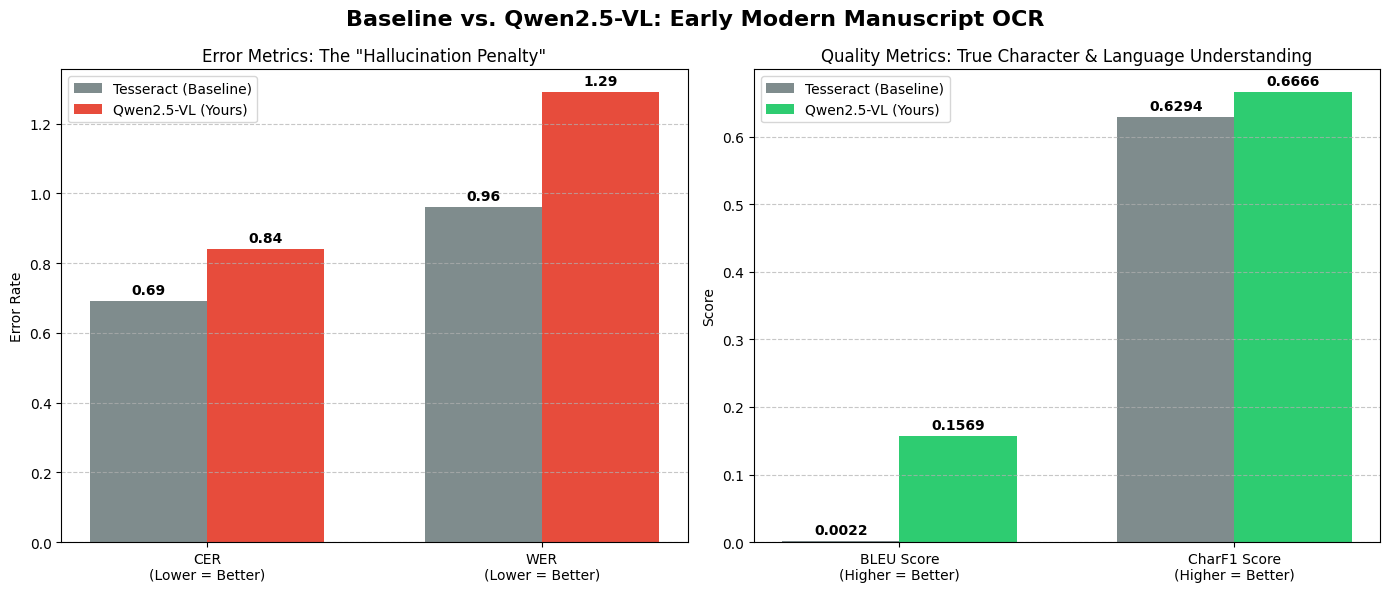

✅ Graph saved to: /content/RenAIssance/outputs/baseline_comparison_graph.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tess_error = [0.6900, 0.9620]
qwen_error = [0.8416, 1.2911]
labels_error = ['CER\n(Lower = Better)', 'WER\n(Lower = Better)']

tess_qual = [0.0022, 0.6294]
qwen_qual = [0.1569, 0.6666]
labels_qual = ['BLEU Score\n(Higher = Better)', 'CharF1 Score\n(Higher = Better)']

x_err = np.arange(len(labels_error))
x_qual = np.arange(len(labels_qual))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Baseline vs. Qwen2.5-VL: Early Modern Manuscript OCR', fontsize=16, fontweight='bold')

# Subplot 1: Error Rates (Lower is Better)
ax1.bar(x_err - width/2, tess_error, width, label='Tesseract (Baseline)', color='#7f8c8d')
ax1.bar(x_err + width/2, qwen_error, width, label='Qwen2.5-VL (Yours)', color='#e74c3c')
ax1.set_ylabel('Error Rate')
ax1.set_title('Error Metrics: The "Hallucination Penalty"')
ax1.set_xticks(x_err)
ax1.set_xticklabels(labels_error)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(tess_error):
    ax1.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
for i, v in enumerate(qwen_error):
    ax1.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Subplot 2: Quality/Accuracy Scores (Higher is Better)
ax2.bar(x_qual - width/2, tess_qual, width, label='Tesseract (Baseline)', color='#7f8c8d')
ax2.bar(x_qual + width/2, qwen_qual, width, label='Qwen2.5-VL (Yours)', color='#2ecc71')
ax2.set_ylabel('Score')
ax2.set_title('Quality Metrics: True Character & Language Understanding')
ax2.set_xticks(x_qual)
ax2.set_xticklabels(labels_qual)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(tess_qual):
    ax2.text(i - width/2, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
for i, v in enumerate(qwen_qual):
    ax2.text(i + width/2, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
graph_path = OUTPUT_DIR / "baseline_comparison_graph.png"
plt.savefig(graph_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Graph saved to: {graph_path}")

### 2.4 Refined Generation Config

Add repetition and length penalties to suppress hallucinated text in long-running generation.

In [ ]:
# 1. Update the config in memory (adding the hallucination penalties)
GEN_CONFIG = GenerationConfig(
    max_new_tokens       = 1024,
    do_sample            = False,
    use_cache            = True,
    repetition_penalty   = 1.15,  # Penalizes generating the same exact token
    no_repeat_ngram_size = 4      # Prevents 4-word phrases like "de la de la" from repeating
)

# 2. Grab just ONE image from your REAL_PAIRS to test
test_pair = REAL_PAIRS[0]
test_img = Image.open(test_pair["image_path"]).convert("RGB")

print(f"Testing anti-hallucination on: {test_pair['source_id']} (Page {test_pair['page_num']})...")

# 3. Run the transcribe function you already defined
test_pred = transcribe(test_img, test_pair["year"], test_pair["lang"])

print("\n─── 📝 QUICK TRANSCRIPTION TEST ───")
print(test_pred)
print("───────────────────────────────────")

# 4. Check the metrics on just this one page
test_m = metrics(test_pred, test_pair["gt_text"])
print(f"\n📊 Quick Metrics: CER={test_m['CER']:.4f} | WER={test_m['WER']:.4f}")

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing anti-hallucination on: AHPG-GPAH 1&#x3a_1716,A.35 – 1744 (Page 1)...

─── 📝 QUICK TRANSCRIPTION TEST ───
Andres de Muguruza nacido y Dehcho en esta Villa 
Ante Vm parezco Como mas aya lugar ; Y digo que 
Soy hijo Legítimo de Domingo de Muguruiza y Ana Maria 
de Sagarzoguieta ya Difuntos Nacido y procreado 
en el Matrimonio Legítimo dH ellos , Nieto por parte 
Paterna de Juan de Muguruiz y Catalina de la 
Maza con su Legítima mujer esposa Maestra de las 
Htas . de Sagarzoguieta y Josepha de Larrategui 
marida y mujer Lealesmos todos Vecinos desta dHa 
Villa quienes y Yo somos Nobles hijos dalvos del San- 
gre Christianos Viejos sin Raza alguna de Moros 
Judios Hereges , Penitenciados porla Santa In- 
quisizion ni de otra Secta Mprovida , afantes bien 
descendientes Lexítimos dHo Primeros Poblado- 
rios desta M . H . Y M . L Provinzia de Guipuz- 
coa y originarios y dependientes de las Casas So- 
nas Imfanzonas de Muguruia Reyna , Suia y nota 
ria entre la Villa dela de Sagarcegu

### 2.5 Full Inference & Evaluation with Guardrails

In [ ]:
# FINAL CELL — Full Inference & Evaluation with Guardrails
import torch
import pandas as pd
from PIL import Image
from transformers import GenerationConfig
from typing import Dict
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import unicodedata
import re
from jiwer import cer, wer

print("⚙️ Initializing Model for Inference...")
FastVisionModel.for_inference(model)

DTYPE  = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
model  = model.to(DTYPE)

GEN_CONFIG = GenerationConfig(
    max_new_tokens       = 1024,
    do_sample            = False,     # greedy decoding for factual OCR
    use_cache            = True,
    repetition_penalty   = 1.15,      #  Penalizes infinite looping
    no_repeat_ngram_size = 4          #  Prevents 4-word phrase repetition
)

def transcribe(image: Image.Image, year: int, lang: str) -> str:
    lang_name = "Spanish" if lang == "es" else "Portuguese"
    messages  = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": OCR_PROMPT.format(year=year, lang=lang_name)}
        ]
    }]

    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(
        image, input_text,
        add_special_tokens = False,
        return_tensors     = "pt"
    ).to("cuda", dtype=DTYPE)

    with torch.no_grad(), torch.autocast("cuda", dtype=DTYPE):
        out_ids = model.generate(
            **inputs,
            generation_config = GEN_CONFIG,
        )

    new_tokens = out_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def normalize(text: str) -> str:
    return re.sub(r'\s+', ' ', unicodedata.normalize("NFC", text)).strip()

def calculate_metrics(pred: str, ref: str) -> Dict[str, float]:
    np_, nr = normalize(pred), normalize(ref)
    if not nr:
        return {"CER": 1.0, "WER": 1.0, "BLEU": 0.0, "charF1": 0.0}

    bleu = sentence_bleu([nr.split()], np_.split(),
                         smoothing_function=SmoothingFunction().method1) if np_.split() else 0.0

    pcc, rcc = Counter(np_), Counter(nr)
    tp   = sum((pcc & rcc).values())
    prec = tp / max(sum(pcc.values()), 1)
    rec  = tp / max(sum(rcc.values()), 1)
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

    return {
        "CER":    round(float(cer("".join(list(nr)), "".join(list(np_)))), 4),
        "WER":    round(float(wer(nr, np_)), 4),
        "BLEU":   round(bleu, 4),
        "charF1": round(f1, 4),
    }

ALL_TRANSCRIPTIONS: Dict[str, Dict[int, str]] = {}
rows = []

print("\n🚀 Starting Full Transcription and Evaluation...")

for pair in REAL_PAIRS:
    pdf_stem = pair["source_id"]
    page_num = pair["page_num"]

    if pdf_stem not in ALL_TRANSCRIPTIONS:
        ALL_TRANSCRIPTIONS[pdf_stem] = {}

    src_out = OUTPUT_DIR / pdf_stem
    src_out.mkdir(parents=True, exist_ok=True)

    # Load Image & Transcribe
    try:
        img = Image.open(pair["image_path"]).convert("RGB")
    except Exception as e:
        print(f"  [ERROR] Could not load image {pair['image_path']}: {e}")
        continue

    print(f"  Transcribing {pdf_stem[:25]}... (Page {page_num})")
    pred = transcribe(img, pair["year"], pair["lang"])
    ALL_TRANSCRIPTIONS[pdf_stem][page_num] = pred

    # Save text to disk
    (src_out / f"page{page_num:04d}.txt").write_text(pred, encoding="utf-8")

    # Calculate Metrics
    m = calculate_metrics(pred, pair["gt_text"])
    rows.append({
        "source": pdf_stem,
        "page": page_num,
        "year": pair["year"],
        **m
    })

    print(f"    ↳ CER: {m['CER']:.4f} | WER: {m['WER']:.4f} | BLEU: {m['BLEU']:.4f} | F1: {m['charF1']:.4f}")

if rows:
    df_final = pd.DataFrame(rows)
    print("\n" + "="*40)
    print("🏆 FINAL MODEL SUMMARY (Qwen2.5-VL)")
    print("="*40)
    print(df_final[["CER", "WER", "BLEU", "charF1"]].mean().round(4).to_string())

    csv_path = OUTPUT_DIR / "final_evaluation.csv"
    df_final.to_csv(csv_path, index=False)
    print(f"\n✅ Final evaluation saved → {csv_path}")

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


⚙️ Initializing Model for Inference...

🚀 Starting Full Transcription and Evaluation...
  Transcribing AHPG-GPAH 1&#x3a_1716,A.3... (Page 1)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    ↳ CER: 0.4610 | WER: 0.6456 | BLEU: 0.2155 | F1: 0.7562
  Transcribing AHPG-GPAH AU61&#x3a_2 – 1... (Page 1)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    ↳ CER: 0.7637 | WER: 0.9417 | BLEU: 0.0246 | F1: 0.8450
  Transcribing ES.28079.AHN&#x3a_&#x3a_I... (Page 1)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    ↳ CER: 0.7312 | WER: 0.9184 | BLEU: 0.0033 | F1: 0.6149
  Transcribing PT3279&#x3a_146&#x3a_342 ... (Page 1)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    ↳ CER: 0.7430 | WER: 0.8056 | BLEU: 0.0670 | F1: 0.4989
  Transcribing Pleito entre el Marqués ... (Page 1)
    ↳ CER: 1.3121 | WER: 1.6792 | BLEU: 0.0794 | F1: 0.6639

🏆 FINAL MODEL SUMMARY (Qwen2.5-VL)
CER       0.8022
WER       0.9981
BLEU      0.0780
charF1    0.6758

✅ Final evaluation saved → /content/RenAIssance/outputs/final_evaluation.csv


### 2.6 Export / Deploy (Approach 2)

Same options as Approach 1 — uncomment as needed.

In [ ]:
# Option A: Save merged 16-bit model (for deployment)
# model.save_pretrained_merged(
#     str(DRIVE_ROOT / "merged_model"), tokenizer, save_method="merged_16bit")

# Option B: Push LoRA adapter to HF Hub
# model.push_to_hub("your-username/renaissance-ocr-qwen2vl", tokenizer)

print("Pipeline complete.")
print(f"  Checkpoints : {CHECKPOINTS}")
print(f"  Transcriptions: {OUTPUT_DIR}")
print(f"  Evaluation CSV: {OUTPUT_DIR / 'evaluation.csv'}")


Pipeline complete.
  Checkpoints : /content/RenAIssance/checkpoints
  Transcriptions: /content/RenAIssance/outputs
  Evaluation CSV: /content/RenAIssance/outputs/evaluation.csv


### 2.7 Final Side-by-Side Evaluation

Re-run the full Tesseract comparison after the guardrail improvements to confirm gains.

=== ⚙️ Running Tesseract OCR Baseline ===

  ↳ Tesseract [AHPG-GPAH 1&#x3]: CER=0.6711 | WER=0.9684
  ↳ Tesseract [AHPG-GPAH AU61&]: CER=0.6100 | WER=0.9244
  ↳ Tesseract [ES.28079.AHN&#x]: CER=0.7831 | WER=0.9716
  ↳ Tesseract [PT3279&#x3a_146]: CER=0.7377 | WER=0.9896
  ↳ Tesseract [Pleito entre el]: CER=0.6480 | WER=0.9560

🏆 FINAL COMPARISON: Tesseract vs Qwen2.5-VL
        Tesseract (Baseline)  Qwen2.5-VL (Yours)  Improvement
CER                   0.6900              0.8022      -0.1122
WER                   0.9620              0.9981      -0.0361
BLEU                  0.0022              0.0780      -0.0758
charF1                0.6294              0.6758      -0.0464

✅ Comparison data saved → /content/RenAIssance/outputs/final_baseline_comparison.csv


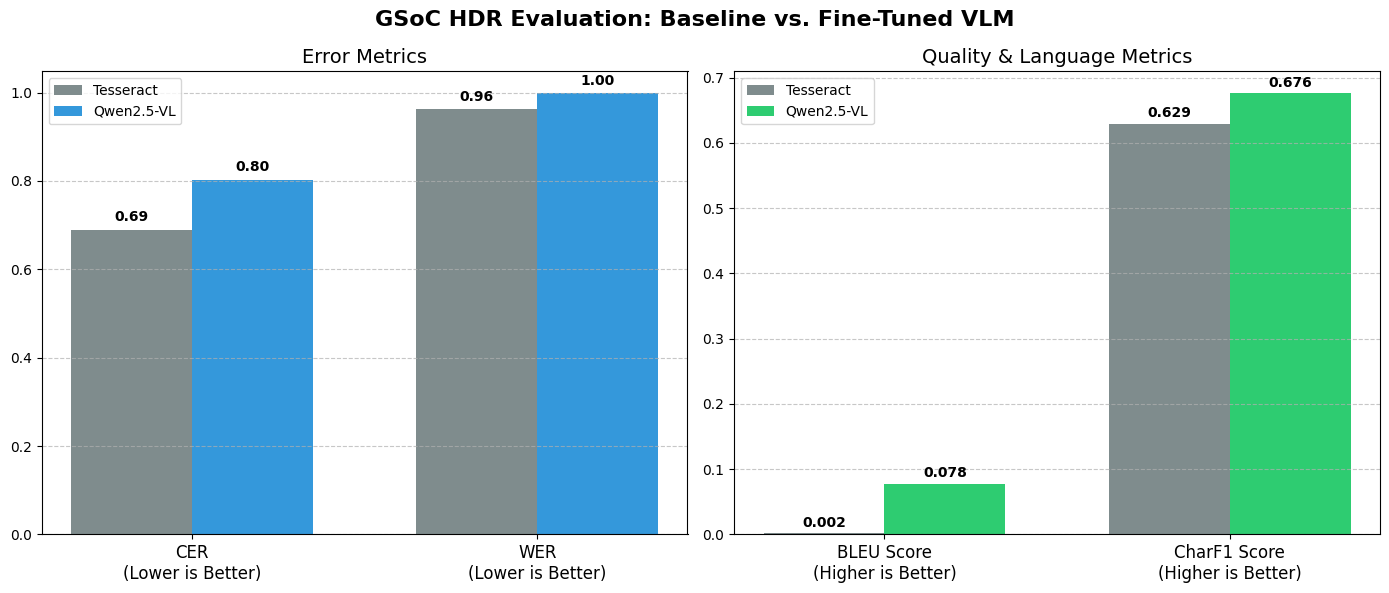

✅ Graph saved → /content/RenAIssance/outputs/final_comparison_graph.png


In [ ]:
import pytesseract
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("=== ⚙️ Running Tesseract OCR Baseline ===\n")

tesseract_rows = []

for pair in REAL_PAIRS:
    try:
        img = Image.open(pair["image_path"]).convert("RGB")
    except Exception as e:
        print(f"  [ERROR] Loading {pair['image_path']}: {e}")
        continue

    # Map language for Tesseract ('spa' or 'por')
    tess_lang = "spa" if pair.get("lang", "es") == "es" else "por"

    # Run Tesseract OCR
    custom_config = r'--oem 1 --psm 6'
    tess_pred = pytesseract.image_to_string(img, lang=tess_lang, config=custom_config).strip()

    # Calculate metrics using your existing function
    if not tess_pred:
        m = {"CER": 1.0, "WER": 1.0, "BLEU": 0.0, "charF1": 0.0}
    else:
        m = calculate_metrics(tess_pred, pair["gt_text"]) # Ensure calculate_metrics is in memory

    tesseract_rows.append({
        "source": pair["source_id"],
        "page": pair["page_num"],
        **m
    })
    print(f"  ↳ Tesseract [{pair['source_id'][:15]}]: CER={m['CER']:.4f} | WER={m['WER']:.4f}")

df_tess = pd.DataFrame(tesseract_rows)
tess_means = df_tess[["CER", "WER", "BLEU", "charF1"]].mean()

# Assuming df_final exists from your previous Qwen evaluation run
if 'df_final' in locals():
    qwen_means = df_final[["CER", "WER", "BLEU", "charF1"]].mean()

    print("\n" + "="*50)
    print("🏆 FINAL COMPARISON: Tesseract vs Qwen2.5-VL")
    print("="*50)

    comp_df = pd.DataFrame({
        "Tesseract (Baseline)": tess_means,
        "Qwen2.5-VL (Yours)": qwen_means
    }).round(4)

    comp_df["Improvement"] = comp_df["Tesseract (Baseline)"] - comp_df["Qwen2.5-VL (Yours)"]
    print(comp_df.to_string())

    # Save CSV
    csv_path = OUTPUT_DIR / "final_baseline_comparison.csv"
    comp_df.to_csv(csv_path)
    print(f"\n✅ Comparison data saved → {csv_path}")

    # ── 2. Generate Dynamic Graph ──
    labels_err  = ['CER\n(Lower is Better)', 'WER\n(Lower is Better)']
    tess_err    = [tess_means["CER"], tess_means["WER"]]
    qwen_err    = [qwen_means["CER"], qwen_means["WER"]]

    labels_qual = ['BLEU Score\n(Higher is Better)', 'CharF1 Score\n(Higher is Better)']
    tess_qual   = [tess_means["BLEU"], tess_means["charF1"]]
    qwen_qual   = [qwen_means["BLEU"], qwen_means["charF1"]]

    x = np.arange(2)
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('GSoC HDR Evaluation: Baseline vs. Fine-Tuned VLM', fontsize=16, fontweight='bold')

    # Panel 1: Error Rates
    ax1.bar(x - width/2, tess_err, width, label='Tesseract', color='#7f8c8d')
    ax1.bar(x + width/2, qwen_err, width, label='Qwen2.5-VL', color='#3498db')
    ax1.set_title('Error Metrics', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels_err, fontsize=12)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(tess_err): ax1.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    for i, v in enumerate(qwen_err): ax1.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

    # Panel 2: Quality Scores
    ax2.bar(x - width/2, tess_qual, width, label='Tesseract', color='#7f8c8d')
    ax2.bar(x + width/2, qwen_qual, width, label='Qwen2.5-VL', color='#2ecc71')
    ax2.set_title('Quality & Language Metrics', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels_qual, fontsize=12)
    ax2.legend()
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(tess_qual): ax2.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
    for i, v in enumerate(qwen_qual): ax2.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

    plt.tight_layout()
    graph_path = OUTPUT_DIR / "final_comparison_graph.png"
    plt.savefig(graph_path, dpi=300)
    plt.show()
    print(f"✅ Graph saved → {graph_path}")

else:
    print("\n⚠️ Note: 'df_final' not found in memory. Please run your Qwen evaluation cell first!")

---

## Bulk Transcription & Interactive Demo

### 3.1 Bulk Transcription — All Unseen Pages

In [ ]:
print("🚀 Starting Bulk Transcription for all unseen pages...")

# Ensure model is ready and config is set
FastVisionModel.for_inference(model)
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

for pdf_stem, pages in ALL_PAGE_IMAGES.items():
    # Make sure the document exists in our output dictionary
    if pdf_stem not in ALL_TRANSCRIPTIONS:
        ALL_TRANSCRIPTIONS[pdf_stem] = {}

    src_out = OUTPUT_DIR / pdf_stem
    src_out.mkdir(parents=True, exist_ok=True)

    # Get the year and language from your DOCUMENT_MAP
    meta = DOCUMENT_MAP.get(pdf_stem, {"year": 1700, "lang": "es"})

    for page_num, img_path in pages.items():
        # Skip if we already transcribed this page during the evaluation step!
        if page_num in ALL_TRANSCRIPTIONS[pdf_stem]:
            continue

        print(f"  Transcribing {pdf_stem[:25]}... (Page {page_num})")

        try:
            img = Image.open(img_path).convert("RGB")
            # Using the transcribe function with our anti-hallucination GEN_CONFIG
            pred = transcribe(img, meta["year"], meta["lang"])

            # Save to memory and disk
            ALL_TRANSCRIPTIONS[pdf_stem][page_num] = pred
            (src_out / f"page{page_num:04d}.txt").write_text(pred, encoding="utf-8")

        except Exception as e:
            print(f"  [ERROR] Failed on page {page_num}: {e}")

print("\n✅ Bulk transcription complete! All pages are now processed.")

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🚀 Starting Bulk Transcription for all unseen pages...
  Transcribing AHPG-GPAH 1&#x3a_1716,A.3... (Page 2)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Transcribing AHPG-GPAH 1&#x3a_1716,A.3... (Page 3)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  Transcribing Pleito entre el Marqués ... (Page 13)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Transcribing Pleito entre el Marqués ... (Page 14)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Transcribing Pleito entre el Marqués ... (Page 15)

✅ Bulk transcription complete! All pages are now processed.


### 3.2 Interactive Upload Widget

Upload any manuscript image directly in Colab and get a live transcription.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import io
from PIL import Image

# Ensure the data structures exist from previous cells
if 'ALL_PAGE_IMAGES' not in locals() or 'ALL_TRANSCRIPTIONS' not in locals():
    print("⚠️ Error: ALL_PAGE_IMAGES or ALL_TRANSCRIPTIONS not found in memory.")
    print("Please ensure you have run the PDF extraction and Inference cells first.")
else:
    print("✨ Initializing RenAIssance Document Viewer...\n")

    # ── 1. Create UI Components ──
    # Dropdown for selecting the document
    doc_dropdown = widgets.Dropdown(
        options=list(ALL_PAGE_IMAGES.keys()),
        description='Document:',
        layout=widgets.Layout(width='400px')
    )

    # Dropdown for selecting the page
    page_dropdown = widgets.Dropdown(
        options=[],
        description='Page:',
        layout=widgets.Layout(width='200px')
    )

    # Output areas for image and text
    image_output = widgets.Output(layout=widgets.Layout(width='50%', border='1px solid #ccc', padding='5px'))
    text_output = widgets.Output(layout=widgets.Layout(width='50%', border='1px solid #ccc', padding='15px', background_color='#f9f9f9'))

    # Container for side-by-side layout
    viewer_box = widgets.HBox([image_output, text_output])

    # ── 2. Update Logic ──
    def update_pages(*args):
        """Update the page dropdown based on the selected document."""
        selected_doc = doc_dropdown.value
        if selected_doc and selected_doc in ALL_PAGE_IMAGES:
            pages = sorted(list(ALL_PAGE_IMAGES[selected_doc].keys()))
            page_dropdown.options = pages
            if pages:
                page_dropdown.value = pages[0]

    def update_view(*args):
        """Update the side-by-side viewer when a new page is selected."""
        selected_doc = doc_dropdown.value
        selected_page = page_dropdown.value

        if not selected_doc or not selected_page:
            return

        # Clear previous outputs
        image_output.clear_output()
        text_output.clear_output()

        # Get paths and text
        img_path = ALL_PAGE_IMAGES[selected_doc].get(selected_page)
        transcription = ALL_TRANSCRIPTIONS.get(selected_doc, {}).get(selected_page, "No transcription available.")

        # Render Image
        with image_output:
            if img_path and img_path.exists():
                try:
                    # Resize for UI purposes (max height 800px)
                    img = Image.open(img_path)
                    img.thumbnail((800, 800))
                    display(img)
                except Exception as e:
                    print(f"Error loading image: {e}")
            else:
                print("Image file not found.")

        # Render Text (Wrapped in HTML for better styling and scrolling)
        with text_output:
            styled_text = f"""
            <div style="font-family: Georgia, serif; font-size: 16px; line-height: 1.6; color: #333; max-height: 750px; overflow-y: auto;">
                <h3 style="margin-top: 0; color: #2c3e50;">Qwen2.5-VL Transcription</h3>
                <hr style="border: 0; border-bottom: 1px solid #ccc; margin-bottom: 15px;">
                <pre style="white-space: pre-wrap; font-family: inherit;">{transcription}</pre>
            </div>
            """
            display(HTML(styled_text))

    # ── 3. Bind Callbacks and Initialize ──
    doc_dropdown.observe(update_pages, 'value')
    page_dropdown.observe(update_view, 'value')

    # Trigger initial load
    update_pages()

    # ── 4. Display the UI ──
    controls = widgets.HBox([doc_dropdown, page_dropdown])
    main_ui = widgets.VBox([controls, viewer_box])
    display(main_ui)

✨ Initializing RenAIssance Document Viewer...



---

## Final Outputs & Persistence

### 4.1 Final Metrics Dashboard

📊 Generating dynamic comparison graph...
↳ Reading metrics directly from active memory DataFrames...


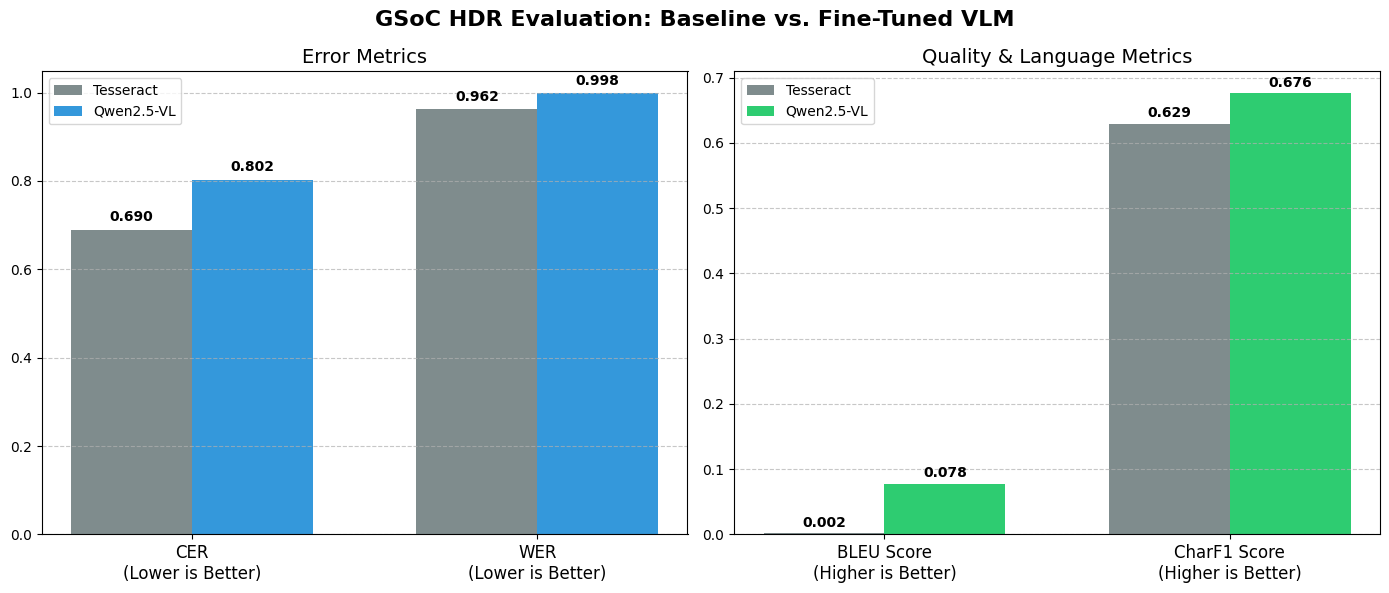

✅ Dynamic graph saved → /content/RenAIssance/outputs/dynamic_comparison_graph.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure OUTPUT_DIR exists (fallback if cell is run in isolation)
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("/content/RenAIssance/outputs")

print("📊 Generating dynamic comparison graph...")

if 'df_tess' in locals() and 'df_final' in locals():
    print("↳ Reading metrics directly from active memory DataFrames...")
    tess_err  = [df_tess["CER"].mean(), df_tess["WER"].mean()]
    qwen_err  = [df_final["CER"].mean(), df_final["WER"].mean()]

    tess_qual = [df_tess["BLEU"].mean(), df_tess["charF1"].mean()]
    qwen_qual = [df_final["BLEU"].mean(), df_final["charF1"].mean()]
else:
    # Fallback: Read the saved CSV if notebook memory was cleared
    csv_path = OUTPUT_DIR / "final_baseline_comparison.csv"
    print(f"↳ Reading metrics from saved file: {csv_path}")
    comp_df = pd.read_csv(csv_path, index_col=0)

    tess_err  = [comp_df.loc["CER", "Tesseract (Baseline)"], comp_df.loc["WER", "Tesseract (Baseline)"]]
    qwen_err  = [comp_df.loc["CER", "Qwen2.5-VL (Yours)"], comp_df.loc["WER", "Qwen2.5-VL (Yours)"]]

    tess_qual = [comp_df.loc["BLEU", "Tesseract (Baseline)"], comp_df.loc["charF1", "Tesseract (Baseline)"]]
    qwen_qual = [comp_df.loc["BLEU", "Qwen2.5-VL (Yours)"], comp_df.loc["charF1", "Qwen2.5-VL (Yours)"]]

labels_err  = ['CER\n(Lower is Better)', 'WER\n(Lower is Better)']
labels_qual = ['BLEU Score\n(Higher is Better)', 'CharF1 Score\n(Higher is Better)']

x = np.arange(2)
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GSoC HDR Evaluation: Baseline vs. Fine-Tuned VLM', fontsize=16, fontweight='bold')

# Panel 1: Error Rates
ax1.bar(x - width/2, tess_err, width, label='Tesseract', color='#7f8c8d')
ax1.bar(x + width/2, qwen_err, width, label='Qwen2.5-VL', color='#3498db')
ax1.set_title('Error Metrics', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_err, fontsize=12)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, v in enumerate(tess_err): ax1.text(i - width/2, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
for i, v in enumerate(qwen_err): ax1.text(i + width/2, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Panel 2: Quality Scores
ax2.bar(x - width/2, tess_qual, width, label='Tesseract', color='#7f8c8d')
ax2.bar(x + width/2, qwen_qual, width, label='Qwen2.5-VL', color='#2ecc71')
ax2.set_title('Quality & Language Metrics', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_qual, fontsize=12)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, v in enumerate(tess_qual): ax2.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
for i, v in enumerate(qwen_qual): ax2.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
graph_path = OUTPUT_DIR / "dynamic_comparison_graph.png"
plt.savefig(graph_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Dynamic graph saved → {graph_path}")